# Генерация карт траекторий игроков NBA (DCGAN)

Учебный ноутбук к Задаче 4: построить GAN, который рисует реалистичные карты
траекторий движения игрока за один эпизод атаки.

## Идея

Одна картинка - это путь одного атакующего игрока за один эпизод (бросок, промах
или потеря). Поле NBA 94x50 футов растянуто в картинку 64x128. Все атаки
зеркалированы так, чтобы корзина была справа. GAN учится воспроизводить
пространственные паттерны движения: дуги к кольцу, проходы, движения по периметру.

## Что было не так в первой версии

Раньше траектория рисовалась тонкой линией в 2 пикселя поверх бледной схемы корта.
Для пиксельного GAN это почти невозможная задача: картинка на 95 процентов белая,
сигнал редкий и высокочастотный, и генератор превращает тонкую линию в серую кашу.
Размер модели тут не помогает (пробовали и 10M, и 1.8M параметров).

## Новый подход

1. Рендеринг, дружелюбный к GAN: толстая сглаженная линия, без схемы корта. Плавные
   градиенты сеть учит легко.
2. Сначала тест на переобучение 200 картинок (должен заучить их наизусть). Это
   главная проверка: если сеть не может выучить 200 примеров, идти дальше нет смысла.
3. Потом полный прогон на demo-наборе около 40k картинок.

## План ноутбука

0. Введение  1. Настройка  2. Данные  3. Генератор  4. Дискриминатор
5. Лосс и оптимизаторы  6. Функция обучения с живыми графиками  7. Запуск
8. Кривые обучения  9. Генерация (inference)  10. Метрики IS и FID
11. Сравнение real vs fake  12. Сборка результатов


## 1. Настройка

Импорты, фиксация случайного зерна для воспроизводимости, выбор устройства.


In [16]:
# Очистка /kaggle/working: удаляет все файлы и подпапки, саму папку оставляет.
import shutil
from pathlib import Path

WORK = Path("/kaggle/working")
removed = 0
for item in WORK.iterdir():
    try:
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()
        removed += 1
    except Exception as exc:
        print("пропущено:", item.name, repr(exc))

print(f"Очищено объектов: {removed}")
print("Осталось в working:", [p.name for p in WORK.iterdir()])


Очищено объектов: 5
Осталось в working: []


In [17]:
import os, time, math, random, json, zipfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# Картинка: высота 64, ширина 128 (пропорции корта 2:1)
IMG_H, IMG_W = 64, 128
Z_DIM = 100
WORK = Path("/kaggle/working")
WORK.mkdir(parents=True, exist_ok=True)

device: cuda
gpu: Tesla T4


## 2. Данные

Датасет - это папка с PNG (64x128, RGB). На Kaggle он подключается в
`/kaggle/input/...`. Ячейка ниже сама находит папку с подпапкой `train`.

Картинки переводятся в тензоры и нормируются в диапазон [-1, 1], потому что
генератор заканчивается активацией Tanh, которая выдает значения в [-1, 1].
Дискриминатор должен видеть реальные и сгенерированные картинки в одном масштабе.


In [18]:
def find_data_root():
    """Найти папку датасета: ищем директорию с подпапкой train в /kaggle/input."""
    base = Path("/kaggle/input")
    if base.exists():
        for p in sorted(base.rglob("train")):
            if p.is_dir():
                return p.parent
    # запасной вариант для локального запуска
    local = Path("D:/nba-motions-data/demo")
    if (local / "train").exists():
        return local
    raise FileNotFoundError("Не найдена папка датасета с подпапкой train")

DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
print("data root:", DATA_ROOT)
print("train PNG:", len(list(TRAIN_DIR.glob("*.png"))))
if TEST_DIR.exists():
    print("test PNG:", len(list(TEST_DIR.glob("*.png"))))


class TrajectoryDataset(Dataset):
    """Читает PNG из папки и нормирует в [-1, 1]."""

    def __init__(self, folder):
        self.files = sorted(Path(folder).glob("*.png"))
        if not self.files:
            raise FileNotFoundError(f"Нет PNG в {folder}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        arr = np.asarray(img, dtype=np.float32) / 255.0      # [0, 1]
        t = torch.from_numpy(arr).permute(2, 0, 1)           # CHW
        return t * 2.0 - 1.0                                 # [-1, 1]


full_train = TrajectoryDataset(TRAIN_DIR)
print("train dataset size:", len(full_train))

data root: /kaggle/input/datasets/olegsadykhov/trajectories-demo-40k
train PNG: 40000
test PNG: 3000
train dataset size: 40000


Посмотрим на реальные примеры. Функция `denorm` возвращает тензор из [-1, 1]
обратно в [0, 1] для отрисовки.


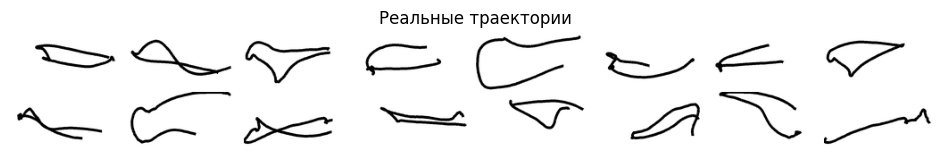

In [19]:
def denorm(x):
    return (x.clamp(-1, 1) + 1.0) / 2.0

def show_grid(batch, nrow=8, title=None, figsize=(12, 4)):
    grid = vutils.make_grid(denorm(batch.cpu()), nrow=nrow, padding=2, pad_value=1.0)
    plt.figure(figsize=figsize)
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()

sample = torch.stack([full_train[i] for i in range(16)])
show_grid(sample, nrow=8, title="Реальные траектории")

## 3. Генератор

Генератор превращает вектор шума `z` (100 чисел из нормального распределения) в
картинку 3x64x128. Схема в духе примера из задания:

```
z(100) -> Linear -> reshape (256, 8, 16)
       -> ConvTranspose 128, stride 2 -> (128, 16, 32)
       -> ConvTranspose  64, stride 2 -> (64, 32, 64)
       -> ConvTranspose   3, stride 2 -> (3, 64, 128) -> Tanh
```

После каждой ConvTranspose (кроме последней) идет BatchNorm и ReLU. Каждый слой с
шагом 2 удваивает высоту и ширину. Tanh в конце дает значения в [-1, 1].


In [20]:
def weights_init(m):
    """Инициализация DCGAN: веса сверток N(0, 0.02), BatchNorm N(1, 0.02)."""
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)
    elif "Linear" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)


class Generator(nn.Module):
    def __init__(self, z_dim=100, ngf=32, out_ch=3):
        super().__init__()
        self.z_dim = z_dim
        self.init_ch = ngf * 8                       # 256 каналов на 8x16
        self.proj = nn.Linear(z_dim, self.init_ch * 8 * 16)
        self.net = nn.Sequential(
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),  # -> 16x32
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),  # -> 32x64
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, out_ch, 4, 2, 1, bias=False),   # -> 64x128
            nn.Tanh(),
        )
        self.apply(weights_init)

    def forward(self, z):
        x = self.proj(z).view(z.size(0), self.init_ch, 8, 16)
        return self.net(x)


G_test = Generator(Z_DIM)
n_params = sum(p.numel() for p in G_test.parameters())
out = G_test(torch.randn(2, Z_DIM))
print(f"Генератор: {n_params/1e6:.2f}M параметров, выход {tuple(out.shape)}")
del G_test

Генератор: 3.97M параметров, выход (2, 3, 64, 128)


## 4. Дискриминатор

Дискриминатор - это бинарный классификатор: на вход картинка 3x64x128, на выходе
одно число (вероятность того, что картинка настоящая). Три свертки с шагом 2
сжимают 64x128 до 8x16, затем линейный слой и сигмоида.

По канону DCGAN на первой свертке BatchNorm не ставят, дальше BatchNorm и
LeakyReLU. Spectral norm можно включить флагом для большей стабильности, по
умолчанию он выключен (простой вариант, как в примере).


In [21]:
from torch.nn.utils import spectral_norm

class Discriminator(nn.Module):
    def __init__(self, in_ch=3, ndf=32, use_sigmoid=True, spectral=False):
        super().__init__()
        self.use_sigmoid = use_sigmoid

        def block(ci, co, bn):
            conv = nn.Conv2d(ci, co, 4, 2, 1, bias=not bn)
            if spectral:
                conv = spectral_norm(conv)
            layers = [conv]
            if bn:
                layers.append(nn.BatchNorm2d(co))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.body = nn.Sequential(
            *block(in_ch, ndf, bn=False),        # -> 32x64
            *block(ndf, ndf * 2, bn=True),       # -> 16x32
            *block(ndf * 2, ndf * 4, bn=True),   # -> 8x16
        )
        head = nn.Linear(ndf * 4 * 8 * 16, 1)
        self.head = spectral_norm(head) if spectral else head
        self.apply(weights_init)

    def forward(self, x):
        feat = self.body(x).flatten(1)
        out = self.head(feat).squeeze(1)
        return torch.sigmoid(out) if self.use_sigmoid else out


D_test = Discriminator()
n_params = sum(p.numel() for p in D_test.parameters())
out = D_test(torch.randn(2, 3, IMG_H, IMG_W))
print(f"Дискриминатор: {n_params/1e6:.2f}M параметров, выход {tuple(out.shape)}")
del D_test

Дискриминатор: 0.18M параметров, выход (2,)


## 5. Лосс и оптимизаторы

Обычный GAN-лосс через бинарную кросс-энтропию (BCE).

- Дискриминатор хочет ставить 1 настоящим и 0 поддельным.
- Генератор хочет, чтобы дискриминатор ставил его подделкам 1.

Прием one-sided label smoothing: вместо метки 1 для настоящих берем 0.9. Это не
дает дискриминатору быть слишком самоуверенным и стабилизирует обучение.

Оптимизатор Adam с lr=2e-4 и beta1=0.5 - стандарт для DCGAN (beta1=0.5 вместо 0.9
дает меньше инерции, обучение GAN от этого ровнее).


## 6. Функция обучения с живыми графиками

`train_gan` это один цельный цикл обучения. Считаем не эпохами, а шагами: один
шаг это один апдейт по случайному батчу. Так понятнее, сколько раз реально
обновились сети (на 200 картинках 300 эпох это всего 900 шагов, а GAN-у нужны
десятки тысяч). На каждом шаге:

1. Шаг дискриминатора: лосс на настоящих и на поддельных картинках.
2. `g_steps` шагов генератора: пытаемся обмануть дискриминатор. Делаем 2 шага G
   на 1 шаг D, и lr дискриминатора ниже (TTUR). Так дискриминатор не убегает
   вперед и не давит генератор в ноль градиента.

Источник батчей выбирается флагом `preload`. Для маленького набора (оверфит на
200 картинках) грузим весь набор одним тензором на GPU и берем случайные батчи
без DataLoader: это в десятки раз быстрее и без воркер-спама. Для полного набора
`preload=False` и читаем потоком через DataLoader.

Каждые `plot_every` шагов ноутбук перерисовывает живую картину: слева кривые
лоссов D и G, справа сетка из фиксированного шума (один и тот же `z` все время,
чтобы видеть прогресс).

У GAN нет валидационного лосса в привычном смысле: лоссы D и G не должны падать к
нулю, они держатся в равновесии. Если лосс D падает в 0, дискриминатор победил и
генератор перестает учиться.


In [22]:
from IPython.display import clear_output

def live_plot(history, G, fixed_z, device):
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5),
                                   gridspec_kw={"width_ratios": [1, 1.3]})
    ax1.plot(history["step"], history["d"], label="D loss", alpha=0.8)
    ax1.plot(history["step"], history["g"], label="G loss", alpha=0.8)
    ax1.set_xlabel("шаг"); ax1.set_ylabel("loss"); ax1.legend()
    ax1.set_title("Кривые обучения")

    G.eval()
    with torch.no_grad():
        fake = G(fixed_z).cpu()
    G.train()
    grid = vutils.make_grid(denorm(fake), nrow=8, padding=2, pad_value=1.0)
    ax2.imshow(grid.permute(1, 2, 0).numpy())
    ax2.axis("off")
    ax2.set_title("Образцы из фиксированного шума")
    plt.tight_layout(); plt.show()


def make_batch_sampler(dataset, batch_size, device, preload):
    """Возвращает функцию next_batch() со случайным батчем настоящих картинок.

    preload=True: грузим весь набор одним тензором на device и берем случайные
    индексы (быстро для маленького оверфита, без DataLoader и воркеров).
    preload=False: читаем потоком через DataLoader (для полного набора).
    """
    if preload:
        data = torch.stack([dataset[i] for i in range(len(dataset))]).to(device)
        n = data.size(0)
        def next_batch():
            idx = torch.randint(0, n, (batch_size,), device=device)
            return data[idx]
        return next_batch

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=2, drop_last=True,
                        pin_memory=(device.type == "cuda"),
                        persistent_workers=True)
    it = iter(loader)
    def next_batch():
        nonlocal it
        try:
            real = next(it)
        except StopIteration:
            it = iter(loader)
            real = next(it)
        return real.to(device, non_blocking=True)
    return next_batch


def train_gan(dataset, device, max_steps, batch_size=64, z_dim=100,
              lr_g=2e-4, lr_d=1e-4, g_steps=2, label_smooth=0.9,
              loss="bce", spectral=False,
              plot_every=500, save_every=0, preload=True,
              ckpt_path=str(WORK / "gan.pt")):
    next_batch = make_batch_sampler(dataset, batch_size, device, preload)

    G = Generator(z_dim).to(device)
    # hinge работает с сырым скором (use_sigmoid=False), bce - с вероятностью.
    D = Discriminator(use_sigmoid=(loss == "bce"), spectral=spectral).to(device)
    # TTUR: дискриминатор учится медленнее генератора.
    optG = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))
    bce = nn.BCELoss() if loss == "bce" else None

    fixed_z = torch.randn(32, z_dim, device=device)
    history = {"step": [], "d": [], "g": []}
    t0 = time.time()

    pbar = tqdm(range(1, max_steps + 1), desc="обучение")
    for step in pbar:
        real = next_batch()
        bs = real.size(0)

        # --- шаг дискриминатора ---
        optD.zero_grad(set_to_none=True)
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)
        d_real = D(real)
        d_fake = D(fake.detach())
        if loss == "hinge":
            lossD = F.relu(1.0 - d_real).mean() + F.relu(1.0 + d_fake).mean()
        else:
            lossD = bce(d_real, torch.full_like(d_real, label_smooth)) +                     bce(d_fake, torch.zeros_like(d_fake))
        lossD.backward(); optD.step()

        # --- g_steps шагов генератора ---
        for _ in range(g_steps):
            optG.zero_grad(set_to_none=True)
            z = torch.randn(bs, z_dim, device=device)
            d_fake2 = D(G(z))
            if loss == "hinge":
                lossG = -d_fake2.mean()
            else:
                lossG = bce(d_fake2, torch.ones_like(d_fake2))
            lossG.backward(); optG.step()

        pbar.set_postfix(D=f"{lossD.item():.3f}", G=f"{lossG.item():.3f}")
        if step % plot_every == 0 or step == max_steps:
            history["step"].append(step)
            history["d"].append(lossD.item())
            history["g"].append(lossG.item())
            live_plot(history, G, fixed_z, device)

        # Периодический бэкап: чекпоинт + сетка образцов на диск. Длинный прогон
        # переживет дисконнект сессии (последний чекпоинт всегда лежит в working).
        if save_every and (step % save_every == 0):
            torch.save({"G": G.state_dict(), "D": D.state_dict(), "z_dim": z_dim},
                       ckpt_path)
            G.eval()
            with torch.no_grad():
                snap = G(fixed_z).cpu()
            G.train()
            vutils.save_image(denorm(snap), WORK / f"samples_step_{step:06d}.png", nrow=8)

    torch.save({"G": G.state_dict(), "D": D.state_dict(), "z_dim": z_dim},
               ckpt_path)
    print(f"Готово за {(time.time()-t0)/60:.1f} мин, {max_steps} шагов. Чекпоинт: {ckpt_path}")
    return G, D, history

## 7. Запуск

Сначала тест на переобучение: берем 200 картинок и учим много шагов (около 15000).
Образцы из фиксированного шума должны постепенно стать похожи на настоящие толстые
траектории. Это доказывает, что архитектура и представление данных в принципе
способны выучить задачу. На 200 картинках с preload на GPU это считается за
несколько минут.

Переключите `OVERFIT = False` для полного прогона на demo-наборе.


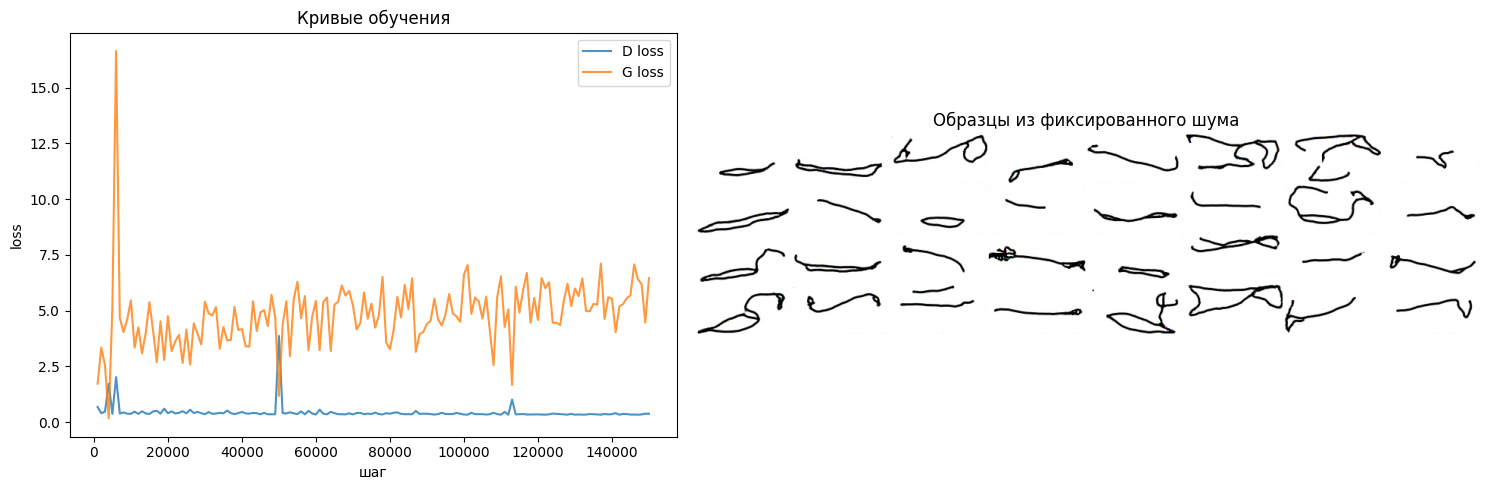

Готово за 260.8 мин, 150000 шагов. Чекпоинт: /kaggle/working/gan.pt


In [23]:
OVERFIT = False   # сначала True (проверка), потом False (полный прогон)
LOSS = "bce"     # "bce" или "hinge"
SPECTRAL = False # spectral_norm в дискриминаторе

# Диагностика "почему полые контуры": бисекция размера набора. 200 заучивается в
# залитые штрихи, 40k уходит в полые контуры. Меняя N_SUBSET (200 -> 2000 -> 5000
# -> 10000) при том же числе показов на картинку, находим, где заливка ломается.
# Если ломается уже на 2-5k - дело в рендере (нужен перерендер), а не в экспозиции.
N_SUBSET = 2000

if OVERFIT:
    idx = list(range(min(N_SUBSET, len(full_train))))
    train_ds = Subset(full_train, idx)
    # бюджет шагов растет с набором, но ограничен ~40000 (около 35 мин на T4)
    max_steps = min(40000, max(15000, len(train_ds) * 20))
    plot_every = max(500, max_steps // 30)
    save_every = 0          # оверфит короткий, бэкап не нужен
    batch_size = 64
    preload = True          # до ~10k картинок влезает в память T4
    print(f"Режим overfit: {len(train_ds)} картинок, {max_steps} шагов (preload на GPU)")
else:
    train_ds = full_train
    max_steps = 150000
    plot_every = 1000
    save_every = 5000       # бэкап чекпоинта и образцов каждые 5000 шагов
    batch_size = 128
    preload = True
    print(f"Полный прогон: {len(train_ds)} картинок, {max_steps} шагов")

# g_steps=1: один шаг G на один шаг D. Раньше было 2, и при пониженном lr
# дискриминатора генератор убегал в один режим (mode collapse).
G, D, history = train_gan(train_ds, device=DEVICE, max_steps=max_steps,
                          batch_size=batch_size, z_dim=Z_DIM, g_steps=1,
                          loss=LOSS, spectral=SPECTRAL,
                          plot_every=plot_every, save_every=save_every,
                          preload=preload)

## 8. Кривые обучения

Итоговый график лоссов. Здоровая картина: лоссы D и G колеблются и держатся в
равновесии, ни один не уходит в 0.


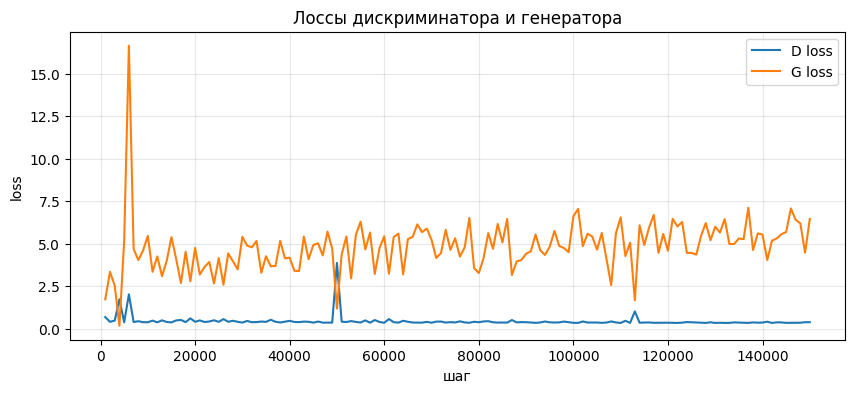

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(history["step"], history["d"], label="D loss")
plt.plot(history["step"], history["g"], label="G loss")
plt.xlabel("шаг"); plt.ylabel("loss"); plt.legend()
plt.title("Лоссы дискриминатора и генератора")
plt.grid(alpha=0.3)
plt.show()

In [25]:
history["d"]

[0.6823800802230835,
 0.4020604193210602,
 0.4762711524963379,
 1.7301207780838013,
 0.3719307482242584,
 2.0186567306518555,
 0.3928292393684387,
 0.4385072886943817,
 0.38176804780960083,
 0.37780052423477173,
 0.473266065120697,
 0.37491375207901,
 0.49047037959098816,
 0.39432886242866516,
 0.3704666793346405,
 0.48582926392555237,
 0.5127331018447876,
 0.38573241233825684,
 0.608267068862915,
 0.4041662812232971,
 0.48521044850349426,
 0.3926922082901001,
 0.42115622758865356,
 0.49456194043159485,
 0.401614248752594,
 0.5620440244674683,
 0.40774452686309814,
 0.4648793339729309,
 0.405548095703125,
 0.3573448061943054,
 0.4559144079685211,
 0.3785949647426605,
 0.38822078704833984,
 0.41946345567703247,
 0.4010557234287262,
 0.5223644971847534,
 0.40825939178466797,
 0.3635064661502838,
 0.4084157347679138,
 0.45957255363464355,
 0.3957291841506958,
 0.3859110474586487,
 0.4149361252784729,
 0.4064725339412689,
 0.3551235795021057,
 0.41868796944618225,
 0.35565185546875,
 0.358

## 9. Генерация (inference)

У GAN нет классического режима инференса как у классификатора. Генерация это
просто: перевести генератор в `eval` (чтобы BatchNorm работал в режиме оценки),
насэмплировать случайный шум `z` и прогнать через генератор. Каждый новый `z`
дает новую траекторию.


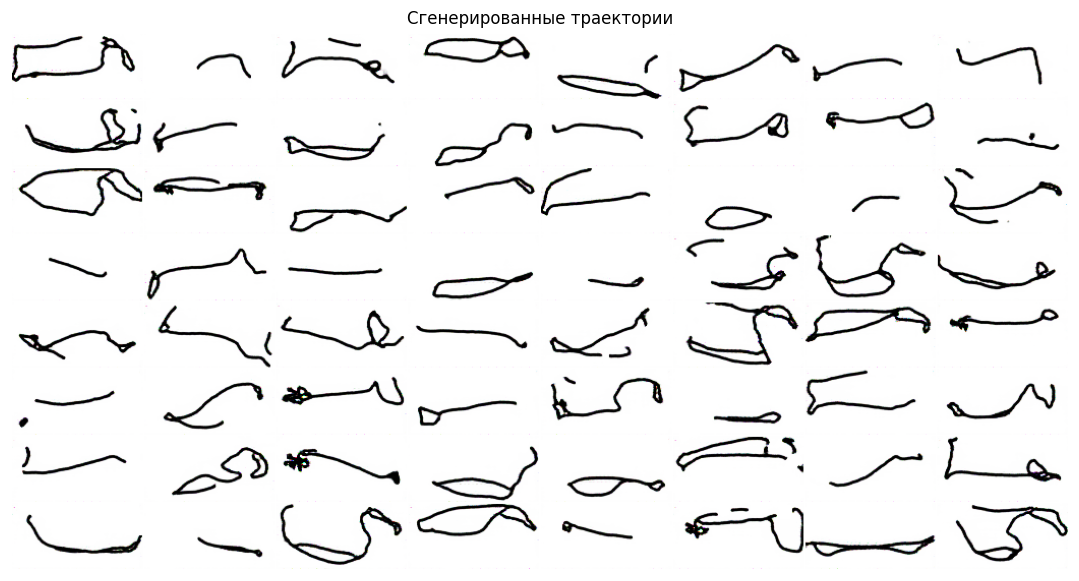

In [26]:
@torch.no_grad()
def generate(G, n, z_dim=100, device=DEVICE):
    G.eval()
    z = torch.randn(n, z_dim, device=device)
    fake = G(z).cpu()
    G.train()
    return fake

samples = generate(G, 64, z_dim=Z_DIM)
show_grid(samples, nrow=8, title="Сгенерированные траектории", figsize=(14, 7))

## 10. Метрики: IS и FID

Задание требует Inception Score (IS) и Frechet Inception Distance (FID). Обе
метрики используют сеть InceptionV3, обученную на ImageNet.

- IS меряет качество и разнообразие сгенерированных картинок (больше - лучше).
- FID меряет расстояние между распределениями признаков настоящих и поддельных
  картинок (меньше - лучше). Считаем FID на отложенном test-наборе, который сеть
  не видела при обучении.

Важная оговорка: InceptionV3 обучена на фотографиях, а у нас штриховые рисунки.
Поэтому IS и FID тут - это приближение. На абстрактных линиях абсолютные значения
не так показательны, как глазами оцененное сходство. Но динамику отслеживать
полезно: при улучшении генерации FID должен падать.


In [27]:
import torchvision.models as tv_models
from scipy import linalg

_INC_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_INC_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def _prep_for_inception(x, device):
    """x в [-1, 1] или [0, 1] -> 299x299, нормировка ImageNet."""
    x = x.float()
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    return (x - _INC_MEAN.to(device)) / _INC_STD.to(device)


class InceptionFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        net = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1,
                                     aux_logits=True)
        net.eval()
        self.fc = net.fc
        net.fc = nn.Identity()
        self.net = net

    @torch.no_grad()
    def forward(self, x):
        pool = self.net(x)
        if isinstance(pool, tuple):
            pool = pool[0]
        logits = self.fc(pool)
        probs = F.softmax(logits, dim=1)
        return probs.cpu().numpy(), pool.cpu().numpy()


@torch.no_grad()
def collect_features(extractor, images_iter, device, batch_size=50):
    probs_all, feats_all = [], []
    for i in range(0, len(images_iter), batch_size):
        batch = images_iter[i:i + batch_size].to(device)
        batch = _prep_for_inception(batch, device)
        p, f = extractor(batch)
        probs_all.append(p); feats_all.append(f)
    return np.concatenate(probs_all), np.concatenate(feats_all)


def inception_score(probs, splits=10):
    n = probs.shape[0]
    splits = max(1, min(splits, n))
    scores = []
    for i in range(splits):
        part = probs[i * n // splits:(i + 1) * n // splits]
        py = np.mean(part, axis=0, keepdims=True)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        scores.append(float(np.exp(np.mean(np.sum(kl, axis=1)))))
    return float(np.mean(scores)), float(np.std(scores))


def frechet_distance(a_real, a_fake, eps=1e-6):
    mu_r, mu_f = a_real.mean(0), a_fake.mean(0)
    sig_r, sig_f = np.cov(a_real, rowvar=False), np.cov(a_fake, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = linalg.sqrtm(sig_r.dot(sig_f), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sig_r.shape[0]) * eps
        covmean = linalg.sqrtm((sig_r + offset).dot(sig_f + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r) + np.trace(sig_f) - 2 * np.trace(covmean))

In [28]:
N_EVAL = 1000

# real_ds определяем заранее: он нужен и метрикам, и сетке сравнения ниже,
# поэтому не должен зависеть от загрузки InceptionV3.
real_dir = TEST_DIR if TEST_DIR.exists() else TRAIN_DIR
real_ds = TrajectoryDataset(real_dir)

# IS и FID требуют скачать веса InceptionV3, а значит включенный Internet в
# настройках ноутбука Kaggle (Settings -> Internet -> On). Если сети нет, метрики
# пропускаем, но обучение и сетка сравнения ниже все равно отработают.
metrics = None
try:
    extractor = InceptionFeatures().to(DEVICE)

    fake_imgs = generate(G, N_EVAL, z_dim=Z_DIM)
    fake_probs, fake_feats = collect_features(extractor, fake_imgs, DEVICE)
    is_mean, is_std = inception_score(fake_probs, splits=10)
    print(f"Inception Score: {is_mean:.3f} +/- {is_std:.3f}")

    n_real = min(N_EVAL, len(real_ds))
    real_imgs = torch.stack([real_ds[i] for i in range(n_real)])
    _, real_feats = collect_features(extractor, real_imgs, DEVICE)
    fid = frechet_distance(real_feats, fake_feats[:n_real])
    print(f"FID: {fid:.3f} (на {n_real} картинках из {real_dir.name})")

    metrics = {"inception_score_mean": is_mean, "inception_score_std": is_std,
               "fid": fid, "n_real": int(n_real), "n_fake": int(N_EVAL)}
    with open(WORK / "metrics.json", "w") as fh:
        json.dump(metrics, fh, indent=2)
    print(metrics)
except Exception as exc:
    print("Метрики пропущены:", repr(exc))
    print("Скорее всего выключен Internet (нужен для весов InceptionV3).")
    print("Включите Settings -> Internet -> On и перезапустите эту ячейку.")

Inception Score: 2.244 +/- 0.075


/tmp/ipykernel_58/3384538504.py:63: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sig_r.dot(sig_f), disp=False)


FID: 37.902 (на 1000 картинках из test)
{'inception_score_mean': 2.243872809410095, 'inception_score_std': 0.07490956322055198, 'fid': 37.901865226938526, 'n_real': 1000, 'n_fake': 1000}


## 11. Сравнение real vs fake

Главная визуальная проверка: слева настоящие траектории, справа сгенерированные.
Они должны выглядеть похоже по форме и расположению линий.


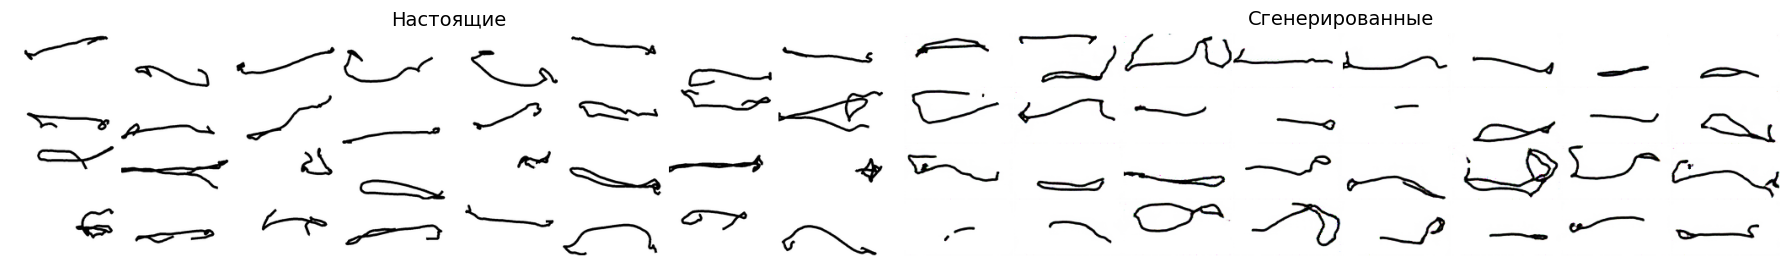

In [104]:
n = 32
real_batch = torch.stack([real_ds[i] for i in range(n)])
fake_batch = generate(G, n, z_dim=Z_DIM)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, batch, title in zip(axes, [real_batch, fake_batch], ["Настоящие", "Сгенерированные"]):
    grid = vutils.make_grid(denorm(batch), nrow=8, padding=2, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(title, fontsize=14); ax.axis("off")
plt.tight_layout()
plt.savefig(WORK / "compare.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Траектории на фоне корта

Финальная визуализация: траектории поверх схемы баскетбольной площадки. Корт
рисуется программно в тот же размер 64x128, что и картинки, и служит только фоном
для презентации (в обучении его нет - схема корта в данных ломала бы пиксельный
GAN). Линии корта серые, траектория поверх черная.

Показываем два ряда по 8 случайных картинок: сверху реальные траектории, снизу
сгенерированные. Обе картинки сохраняются в working (`real_on_court.png`,
`gan_on_court.png`). Все атаки отзеркалены вправо, поэтому целевое кольцо всегда
справа - видно, куда движется игрок.


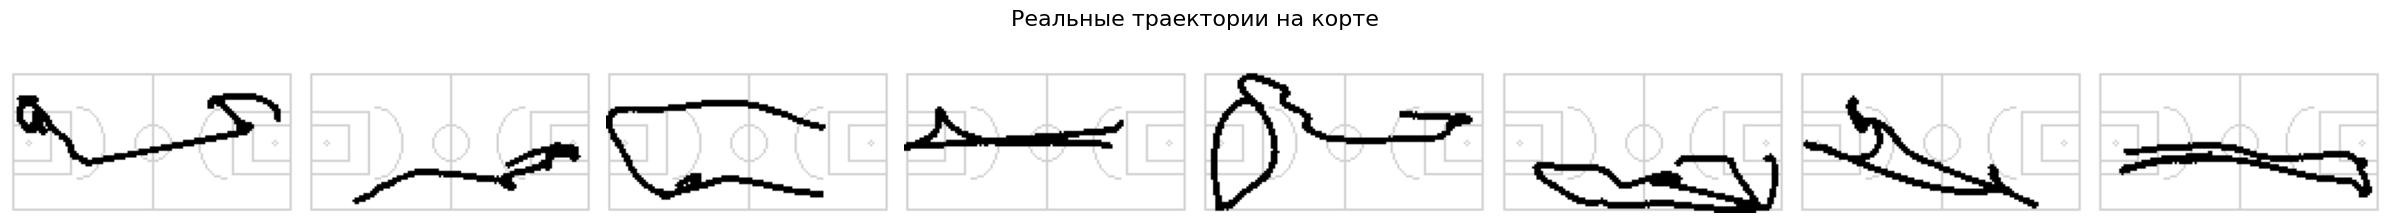

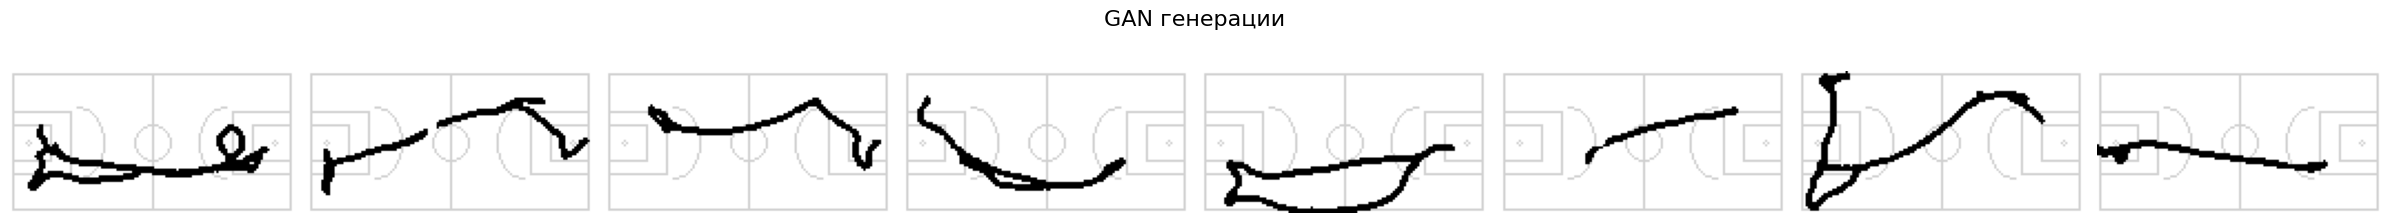

In [107]:
from PIL import ImageDraw

def make_court_template(h=IMG_H, w=IMG_W, line=0.82):
    """Схема корта 64x128: серые линии на белом (только фон, не для обучения)."""
    img = Image.new("L", (w, h), 255)
    d = ImageDraw.Draw(img)
    c = int(line * 255)
    d.rectangle([1, 1, w - 2, h - 2], outline=c, width=1)        # граница
    d.line([w // 2, 1, w // 2, h - 2], fill=c, width=1)          # центральная линия
    d.ellipse([w // 2 - 8, h // 2 - 8, w // 2 + 8, h // 2 + 8], outline=c, width=1)
    for side in ("left", "right"):
        if side == "left":
            hoop_x = 8
            d.rectangle([1, 18, 27, 46], outline=c, width=1)     # дальняя зона
            d.rectangle([1, 24, 18, 40], outline=c, width=1)     # краска
            d.arc([18, 16, 42, 48], start=270, end=90, fill=c, width=1)
        else:
            hoop_x = w - 9
            d.rectangle([w - 28, 18, w - 2, 46], outline=c, width=1)
            d.rectangle([w - 19, 24, w - 2, 40], outline=c, width=1)
            d.arc([w - 43, 16, w - 19, 48], start=90, end=270, fill=c, width=1)
        d.ellipse([hoop_x - 1, h // 2 - 1, hoop_x + 1, h // 2 + 1], outline=c, width=1)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return np.repeat(arr[:, :, None], 3, axis=2)                 # (h, w, 3) в [0, 1]


COURT = make_court_template()

def overlay_on_court(img01):
    """img01: (h, w, 3) в [0, 1], белый фон + темный штрих -> корт + черный штрих."""
    canvas = COURT.copy()
    canvas[img01.mean(axis=2) < 0.5] = 0.0
    return canvas

def show_on_court(batch01, title, path):
    fig, axes = plt.subplots(1, 8, figsize=(24, 2.4))
    for ax, f in zip(axes, batch01):
        ax.imshow(overlay_on_court(f))
        ax.axis("off")
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()

# 8 случайных реальных траекторий на корте
ridx = random.sample(range(len(real_ds)), 8)
real8 = denorm(torch.stack([real_ds[i] for i in ridx])).permute(0, 2, 3, 1).numpy()
show_on_court(real8, "Реальные траектории на корте", WORK / "real_on_court.png")

# 8 сгенерированных траекторий на корте
fake8 = denorm(generate(G, 8, z_dim=Z_DIM)).permute(0, 2, 3, 1).numpy()
show_on_court(fake8, "GAN генерации", WORK / "gan_on_court.png")

## 13. Сборка результатов

Складываем чекпоинт, метрики и картинки в один zip для скачивания.


In [108]:
bundle = WORK / "results_bundle.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as zf:
    for name in ["gan.pt", "metrics.json", "compare.png"]:
        p = WORK / name
        if p.exists():
            zf.write(p, arcname=name)
print("Сохранено:", bundle)

Сохранено: /kaggle/working/results_bundle.zip
